`conda activate multi_integration`

# Joint analysis of paired and unpaired multiomic data with MultiVI

In [ ]:
import numpy as np
import scglue
import scanpy as sc
import anndata as ad
import muon
import scvi

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argum

In [ ]:
import torch

# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available")
    
    # Get the number of available GPUs
    num_gpus = torch.cuda.device_count()
    print(f"Number of available GPUs: {num_gpus}")
    
    # Get the name of each available GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("CUDA is not available")

CUDA is available
Number of available GPUs: 1
GPU 0: NVIDIA A100-SXM4-40GB


```{important}
MultiVI requires the datasets to use shared features. scATAC-seq datasets need to be processed to use a shared set of peaks.
```

In [ ]:
scvi.settings.seed = 420

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

[rank: 0] Global seed set to 420


### Loading RNA files

In [ ]:
adata_rna_multiome = sc.read('data/subset_rna_multi_dmg_atlas.h5ad')
adata_rna_multiome

AnnData object with n_obs × n_vars = 17875 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
scglue.data.get_gene_annotation(
    adata_rna_multiome, gtf="/home/cruiz2/software/refdata-gex-GRCh38-2020-A/genes/genes.gtf",
    gtf_by="gene_name"
)
adata_rna_multiome.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
A1BG,chr19,58345177,58353492
A1CF,chr10,50799408,50885675
A2M,chr12,9067663,9116229
A2ML1,chr12,8822620,8887001
A3GALT2,chr1,33306765,33321098


In [ ]:
# Define a dictionary mapping old names to new names
name_mapping = {
    "chrom": "chr",
    "chromStart": "start",
    "chromEnd": "end",
    # Add more mappings as needed
}

# Iterate over the dictionary and update column names in `.var` attribute
for old_name, new_name in name_mapping.items():
    if old_name in adata_rna_multiome.var.columns:
        adata_rna_multiome.var.rename(columns={old_name: new_name}, inplace=True)

In [ ]:
adata_rna_multiome.obs['Modality'] = 'multiome'

In [ ]:
adata_rna = sc.read('data/subset_rna_only_dmg_atlas.h5ad')
adata_rna

AnnData object with n_obs × n_vars = 31118 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
scglue.data.get_gene_annotation(
    adata_rna, gtf="/home/cruiz2/software/refdata-gex-GRCh38-2020-A/genes/genes.gtf",
    gtf_by="gene_name"
)
adata_rna.var.loc[:, ["chrom", "chromStart", "chromEnd"]].head()

,chrom,chromStart,chromEnd
A1BG,chr19,58345177,58353492
A1CF,chr10,50799408,50885675
A2M,chr12,9067663,9116229
A2ML1,chr12,8822620,8887001
A3GALT2,chr1,33306765,33321098


In [ ]:
# Define a dictionary mapping old names to new names
name_mapping = {
    "chrom": "chr",
    "chromStart": "start",
    "chromEnd": "end",
    # Add more mappings as needed
}

# Iterate over the dictionary and update column names in `.var` attribute
for old_name, new_name in name_mapping.items():
    if old_name in adata_rna.var.columns:
        adata_rna.var.rename(columns={old_name: new_name}, inplace=True)

In [ ]:
adata_rna.obs['Modality'] = 'rna'

### RNA-seq preprocessing

In [ ]:
rna = ad.concat([adata_rna_multiome, adata_rna], 
                join = 'outer', index_unique = None, axis = 0, merge = 'first')
rna

AnnData object with n_obs × n_vars = 48993 × 19248
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
rna.X, rna.X.data

(<48993x19248 sparse matrix of type '<class 'numpy.float64'>'
 	with 106370484 stored elements in Compressed Sparse Row format>,
 array([1., 2., 2., ..., 3., 1., 1.]))

In [ ]:
rna.layers['counts'] = rna.X.copy()
sc.pp.normalize_total(rna, target_sum=1e4)
sc.pp.log1p(rna)
sc.pp.highly_variable_genes(rna, n_top_genes=5000, batch_key='Batch_for_correction')

In [ ]:
rna.X = rna.layers['counts'].copy()
rna = rna[:, rna.var.highly_variable].copy()
rna

AnnData object with n_obs × n_vars = 48993 × 5000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample'

In [ ]:
rna_multiome = rna[rna.obs['Modality'] == 'multiome'].copy()
rna_only = rna[rna.obs['Modality'] == 'rna'].copy()

### Loading ATAC files

In [ ]:
adata_atac_multiome = sc.read('data/subset_atac_multi_dmg_atlas.h5ad')
adata_atac_multiome

AnnData object with n_obs × n_vars = 17875 × 378298
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFi

In [ ]:
adata_atac_multiome.obs['Modality'] = 'multiome'

In [ ]:
split = adata_atac_multiome.var_names.str.split(r"[:-]")
adata_atac_multiome.var["chr"] = split.map(lambda x: x[0])
adata_atac_multiome.var["start"] = split.map(lambda x: x[1]).astype(int)
adata_atac_multiome.var["end"] = split.map(lambda x: x[2]).astype(int)
adata_atac_multiome.var.head()

,count,percentile,chr,start,end
chr1:9729-10741,678.0,0.884990,chr1,9729,10741
chr1:15764-16590,60.0,0.027685,chr1,15764,16590
chr1:17055-17946,87.0,0.109028,chr1,17055,17946
chr1:28900-29821,105.0,0.189356,chr1,28900,29821
chr1:180694-181903,1714.0,0.959090,chr1,180694,181903


In [ ]:
adata_atac = sc.read('data/subset_atac_only_dmg_atlas.h5ad')
adata_atac

AnnData object with n_obs × n_vars = 21804 × 378298
    obs: 'total', 'duplicate', 'chimeric', 'unmapped', 'lowmapq', 'mitochondrial', 'nonprimary', 'passed_filters', 'is__cell_barcode', 'excluded_reason', 'TSS_fragments', 'DNase_sensitive_region_fragments', 'enhancer_region_fragments', 'promoter_region_fragments', 'on_target_fragments', 'blacklist_region_fragments', 'peak_region_fragments', 'peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFinder.class', 'amulet_pvalue', 'amulet_qvalue', 'scDblFinder.p', 'dbl_combined_score', 'ID', 'Study', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired

In [ ]:
split = adata_atac.var_names.str.split(r"[:-]")
adata_atac.var["chr"] = split.map(lambda x: x[0])
adata_atac.var["start"] = split.map(lambda x: x[1]).astype(int)
adata_atac.var["end"] = split.map(lambda x: x[2]).astype(int)
adata_atac.var.head()

,count,percentile,chr,start,end
chr1:9729-10741,121.0,0.168346,chr1,9729,10741
chr1:15764-16590,41.0,0.008834,chr1,15764,16590
chr1:17055-17946,71.0,0.035287,chr1,17055,17946
chr1:28900-29821,16.0,0.001745,chr1,28900,29821
chr1:180694-181903,740.0,0.853930,chr1,180694,181903


In [ ]:
adata_atac.obs['Modality'] = 'atac'

### ATAC-seq preprocessing

In [ ]:
atac = ad.concat([adata_atac_multiome, adata_atac],
                 join = 'outer', index_unique = None, axis = 0, merge = 'first')
atac

AnnData object with n_obs × n_vars = 39679 × 378298
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFi

In [ ]:
atac.layers['counts'] = atac.X.copy()
muon.atac.pp.tfidf(atac, scale_factor=1e4)
atac.layers['tf-idf'] = atac.X.copy()
atac.X = atac.layers['counts'].copy()

sc.pp.normalize_total(atac, target_sum=1e4)
sc.pp.log1p(atac)
sc.pp.highly_variable_genes(atac, n_top_genes=20000, batch_key='Modality')

atac.layers['log-norm'] = atac.X.copy()

In [ ]:
atac.X = atac.layers["counts"].copy()
atac.X, atac.X.data

(<39679x378298 sparse matrix of type '<class 'numpy.float64'>'
 	with 300355021 stored elements in Compressed Sparse Row format>,
 array([2., 1., 2., ..., 1., 1., 1.]))

In [ ]:
atac = atac[:, atac.var.highly_variable].copy()
atac

AnnData object with n_obs × n_vars = 39679 × 20000
    obs: 'gex_barcode', 'atac_barcode', 'is_cell', 'excluded_reason', 'gex_raw_reads', 'gex_mapped_reads', 'gex_conf_intergenic_reads', 'gex_conf_exonic_reads', 'gex_conf_intronic_reads', 'gex_conf_exonic_unique_reads', 'gex_conf_exonic_antisense_reads', 'gex_conf_exonic_dup_reads', 'gex_exonic_umis', 'gex_conf_intronic_unique_reads', 'gex_conf_intronic_antisense_reads', 'gex_conf_intronic_dup_reads', 'gex_intronic_umis', 'gex_conf_txomic_unique_reads', 'gex_umis_count', 'gex_genes_count', 'atac_raw_reads', 'atac_unmapped_reads', 'atac_lowmapq', 'atac_dup_reads', 'atac_chimeric_reads', 'atac_mitochondrial_reads', 'passed_filters', 'atac_TSS_fragments', 'atac_peak_region_fragments', 'atac_peak_region_cutsites', 'nCount_ATAC', 'nFeature_ATAC', 'SampleID', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'pct_reads_in_peaks', 'blacklist_ratio', 'high.tss', 'nucleosome_group', 'scDblFinder.score', 'scDblFin

In [ ]:
atac_multiome = atac[atac.obs['Modality'] == 'multiome'].copy()
atac_only = atac[atac.obs['Modality'] == 'atac'].copy()

In [ ]:
del(rna_multiome.layers)
del(atac_multiome.layers)

In [ ]:
rna_multiome.var['modality'] = 'Gene Expression'
atac_multiome.var['modality'] = 'Peaks'

In [ ]:
adata_paired = ad.concat([rna_multiome, atac_multiome],  
                         join = 'outer', index_unique = None, axis = 1, merge = 'first')
adata_paired

AnnData object with n_obs × n_vars = 17875 × 25000
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_RAW', 'nFeature_RAW', 'DF.class', 'DF.score', 'scDblFinder.class', 'scDblFinder.score', 'ID', 'SampleID', 'Data', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'nFeature_Diff', 'nCount_Diff', 'Batch_for_correction', 'scDblFinder.clusters.class', 'scDblFinder.clusters.score', 'scDblFinder.class.clusters', 'doublet.combn.fisher', 'doublet.combn.mean', 'doublet.combn.fisher.class', 'doublet.combn.mean.class', 'Study', 'Original_annotation', 'Isolation_method_by_cell', 'Cell_type_granular_mouse_correlations', 'Cell_type_mouse_correlations', 'Cell_type_consensus_Jessa2022', 'Malignant_normal_consensus_Jessa2022', 'Institute', 'Preservation_method', 'Diagnosis', 'Tumor_type', 'Tumor_subtype', 'Location', 'Source', 'Clinical_status', 'Isolation_method', 'Sc_platform_RNA', 'Sc_platform_ATAC', 'Sc_multiome', 'Raw_data_available', 'Counts', 'Genome_version', 'Paired_sample

In [ ]:
# We can now use the organizing method from scvi to concatenate these anndata
adata_mvi = scvi.data.organize_multiome_anndatas(adata_paired, rna_only, atac_only)

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/anndata/_core/anndata.py:1755: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


In [ ]:
adata_mvi.obs['modality']

GNG_region_11_AAACATGCACGAACAG-1_paired                       paired
GNG_region_11_AAACCAACACGTTACA-1_paired                       paired
GNG_region_11_AAACCAACATGATTGT-1_paired                       paired
GNG_region_11_AAACGCGCATAAGGAC-1_paired                       paired
GNG_region_11_AAACGTACAATAACCT-1_paired                       paired
                                                           ...      
atac_P-6255_S-8500_TTGCGAAAGGCATGCA-1_accessibility    accessibility
atac_P-6255_S-8500_TTGCTTAGTGTGTGCC-1_accessibility    accessibility
atac_P-6255_S-8500_TTGCTTATCCAACGCG-1_accessibility    accessibility
atac_P-6255_S-8500_TTTACGTTCAGGGTTT-1_accessibility    accessibility
atac_P-6255_S-8500_TTTGTGTCAACGTAGG-1_accessibility    accessibility
Name: modality, Length: 70797, dtype: object

MultiVI requires the features to be ordered, such that genes appear before genomic regions. In this case this is already the case, but it's always good to verify:

In [ ]:
adata_mvi = adata_mvi[:, adata_mvi.var["modality"].argsort()].copy()
adata_mvi.var

,vst.mean,vst.variance,vst.variance.expected,vst.variance.standardized,vst.variable,chr,start,end,name,score,...,havana_gene,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection,modality,count,percentile
A2M,5.611721,15361.999192,7507.142953,2.046318,False,chr12,9067663,9116229,A2M,.,...,OTTHUMG00000150267.7,True,1.038783,2.961622,1.741248,4,True,Gene Expression,NaN,NaN
PLB1,0.188328,118.112210,106.645433,1.107522,False,chr2,28457144,28644142,PLB1,.,...,OTTHUMG00000152014.5,True,0.143187,2.337174,0.901852,3,False,Gene Expression,NaN,NaN
PLAUR,1.658411,7603.841377,1394.998925,4.684553,True,chr19,43646094,43670547,PLAUR,.,...,OTTHUMG00000182778.3,True,0.469619,2.740906,2.208866,4,True,Gene Expression,NaN,NaN
PLAU,0.202258,131.915047,114.279590,1.154319,False,chr10,73909176,73917496,PLAU,.,...,OTTHUMG00000018494.6,True,0.074044,2.057267,0.597324,3,False,Gene Expression,NaN,NaN
PLAT,1.758709,2165.525586,1507.512305,1.436489,False,chr8,42174717,42207676,PLAT,.,...,OTTHUMG00000164072.3,True,0.330595,2.421411,1.148761,3,False,Gene Expression,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr5:36045590-36046505,NaN,NaN,NaN,NaN,NaN,chr5,36045590,36046505,NaN,NaN,...,NaN,True,0.007812,1.453214,3.013801,1,False,Peaks,104.0,0.184640
chr5:35869528-35870380,NaN,NaN,NaN,NaN,NaN,chr5,35869528,35870380,NaN,NaN,...,NaN,True,0.008036,1.069417,1.361606,1,False,Peaks,102.0,0.175304
chr5:35862933-35863859,NaN,NaN,NaN,NaN,NaN,chr5,35862933,35863859,NaN,NaN,...,NaN,True,0.007196,1.119726,1.392557,1,False,Peaks,97.0,0.152441
chr5:36590125-36591404,NaN,NaN,NaN,NaN,NaN,chr5,36590125,36591404,NaN,NaN,...,NaN,True,0.022686,1.065847,1.030416,1,False,Peaks,304.0,0.709570


## Setup and Training MultiVI

We can now set up and train the MultiVI model!

First, we need to setup the Anndata object using the `setup_anndata` function. At this point we specify any batch annotation that the model would account for.
**Importantly**, the main batch annotation, specific by `batch_key`, should correspond to the modality of the cells.

Other batch annotations (e.g if there are multiple ATAC batches) should be provided using the `categorical_covariate_keys`.

The actual values of categorical covariates (include `batch_key`) are not important, as long as they are different for different samples.
I.e it is not important to call the expression-only samples "expression", as long as they are called something different than the multi-modal and accessibility-only samples.

```{important}
MultiVI requires the main batch annotation to correspond to the modality of the samples. Other batch annotation, such as in the case of multiple RNA-only batches, can be specified using `categorical_covariate_keys`.
```

In [ ]:
scvi.model.MULTIVI.setup_anndata(adata_mvi, batch_key="SampleID")

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


When creating the object, we need to specify how many of the features are genes, and how many are genomic regions. This is so MultiVI can determine the exact architecture for each modality.

In [ ]:
mvi = scvi.model.MULTIVI(
    adata_mvi,
    n_genes=(adata_mvi.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata_mvi.var["modality"] == "Peaks").sum(),
)
mvi.view_anndata_setup()

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/torch/nn/init.py:405: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 0.20.3.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'SampleID',
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │  94   │
│         n_cells          │ 70797 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   1   │
│          n_vars          │ 25000 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                            batch State Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃         Categories         ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['SampleID'] │          BT042_PD          │          0          │
│                       │        BT042_pons_1        │          1          │
│                       │        BT042_pons_2        │          2          │
│                       │       BT072_region_1       │          3          │
│                       │       BT072_region_2       │          4          │
│                       │          BT789AAQ          │          5          │
│                       │        GNG_region_6        │          6          │
│                       │       GNG_region_10        │          7          │
│                       │       GNG_region_11        │          8          │
│                       │       GNG_region_12        │          9          │
│                       │            MUV1            │         10          │
│                       │           MUV16            │         11          │
│                       │           MUV35            │         12          │
│                       │           MUV86            │         13          │
│                       │   P-1569_S-1569_RNA_only   │         14          │
│                       │   P-1694_S-1694_Multiome   │         15          │
│                       │   P-1701_S-1701_Multiome   │         16          │
│                       │   P-1709_S-1709_Multiome   │         17          │
│                       │   P-1713_S-1713_RNA_only   │         18          │
│                       │   P-1741_S-2756_RNA_only   │         19          │
│                       │       P-1764_S-1766        │         20          │
│                       │   P-1764_S-1766_Multiome   │         21          │
│                       │   P-1764_S-1766_RNA_only   │         22          │
│                       │   P-1775_S-1775_RNA_only   │         23          │
│                       │   P-1779_S-1781_Multiome   │         24          │
│                       │   P-1780_S-1780_Multiome   │         25          │
│                       │       P-2687_S-2688        │         26          │
│                       │   P-2687_S-2688_RNA_only   │         27          │
│                       │   P-3387_S-3411_RNA_only   │         28          │
│                       │   P-3407_S-3447_RNA_only   │         29          │
│                       │   P-4198_S-4459_RNA_only   │         30          │
│                       │   P-4504_S-4916_RNA_only   │         31          │
│                       │   P-5099_S-6218_RNA_only   │         32          │
│                       │   P-5613_S-7162_RNA_only   │         33          │
│                       │   P-6117_S-8370_RNA_only   │         34          │
│                       │   P-6240_S-8628_RNA_only   │         35          │
│                       │   P-6251_S-8496_RNA_only   │         36          │
│                       │       P-6253_S-8498        │         37          │
│                       │   P-6253_S-8498_Multiome   │         38          │
│                       │   P-6253_S-8498_RNA_only   │         39          │
│                       │   P-6254_S-8499_RNA_only   │         40          │
│                       │       P-6255_S-8500        │         41          │
│                       │   P-6255_S-8500_RNA_only   │         42          │
│                       │   P-6328_S-8672_RNA_only   │         43          │
│                       │   P-6337_S-8821_Multiome   │         44          │
│                       │   P-6337_S-8821_RNA_only   │         45          │
│                       │   P-6519_S-9084_RNA_only   │         46          │
│                       │   P-6640_S-9581_Multiome   │         47        

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                            batch State Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location    ┃         Categories         ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['SampleID'] │          BT042_PD          │          0          │
│                       │        BT042_pons_1        │          1          │
│                       │        BT042_pons_2        │          2          │
│                       │       BT072_region_1       │          3          │
│                       │       BT072_region_2       │          4          │
│                       │          BT789AAQ          │          5          │
│                       │        GNG_region_6        │          6          │
│                       │       GNG_region_10        │          7          │
│                       │       GNG_region_11        │          8          │
│                       │       GNG_region_12        │          9          │
│                       │            MUV1            │         10          │
│                       │           MUV16            │         11          │
│                       │           MUV35            │         12          │
│                       │           MUV86            │         13          │
│                       │   P-1569_S-1569_RNA_only   │         14          │
│                       │   P-1694_S-1694_Multiome   │         15          │
│                       │   P-1701_S-1701_Multiome   │         16          │
│                       │   P-1709_S-1709_Multiome   │         17          │
│                       │   P-1713_S-1713_RNA_only   │         18          │
│                       │   P-1741_S-2756_RNA_only   │         19          │
│                       │       P-1764_S-1766        │         20          │
│                       │   P-1764_S-1766_Multiome   │         21          │
│                       │   P-1764_S-1766_RNA_only   │         22          │
│                       │   P-1775_S-1775_RNA_only   │         23          │
│                       │   P-1779_S-1781_Multiome   │         24          │
│                       │   P-1780_S-1780_Multiome   │         25          │
│                       │       P-2687_S-2688        │         26          │
│                       │   P-2687_S-2688_RNA_only   │         27          │
│                       │   P-3387_S-3411_RNA_only   │         28          │
│                       │   P-3407_S-3447_RNA_only   │         29          │
│                       │   P-4198_S-4459_RNA_only   │         30          │
│                       │   P-4504_S-4916_RNA_only   │         31          │
│                       │   P-5099_S-6218_RNA_only   │         32          │
│                       │   P-5613_S-7162_RNA_only   │         33          │
│                       │   P-6117_S-8370_RNA_only   │         34          │
│                       │   P-6240_S-8628_RNA_only   │         35          │
│                       │   P-6251_S-8496_RNA_only   │         36          │
│                       │       P-6253_S-8498        │         37          │
│                       │   P-6253_S-8498_Multiome   │         38          │
│                       │   P-6253_S-8498_RNA_only   │         39          │
│                       │   P-6254_S-8499_RNA_only   │         40          │
│                       │       P-6255_S-8500        │         41          │
│                       │   P-6255_S-8500_RNA_only   │         42          │
│                       │   P-6328_S-8672_RNA_only   │         43          │
│                       │   P-6337_S-8821_Multiome   │         44          │
│                       │   P-6337_S-8821_RNA_only   │         45          │
│                       │   P-6519_S-9084_RNA_only   │         46          │
│                       │   P-6640_S-9581_Multiome   │         47        

In [ ]:
mvi.train()

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cruiz2/miniconda3/envs/multi_integration/lib/p ...
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/cruiz2/miniconda3/envs/multi_integration/lib/p ...
  rank_zero_warn(
You are using a CUDA device ('NVIDIA A100-SX

Epoch 128/500:  26%|▎| 128/500 [27:22<1:19:33, 12.8
Monitored metric reconstruction_loss_validation did not improve in the last 50 records. Best score: 1596.279. Signaling Trainer to stop.


/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


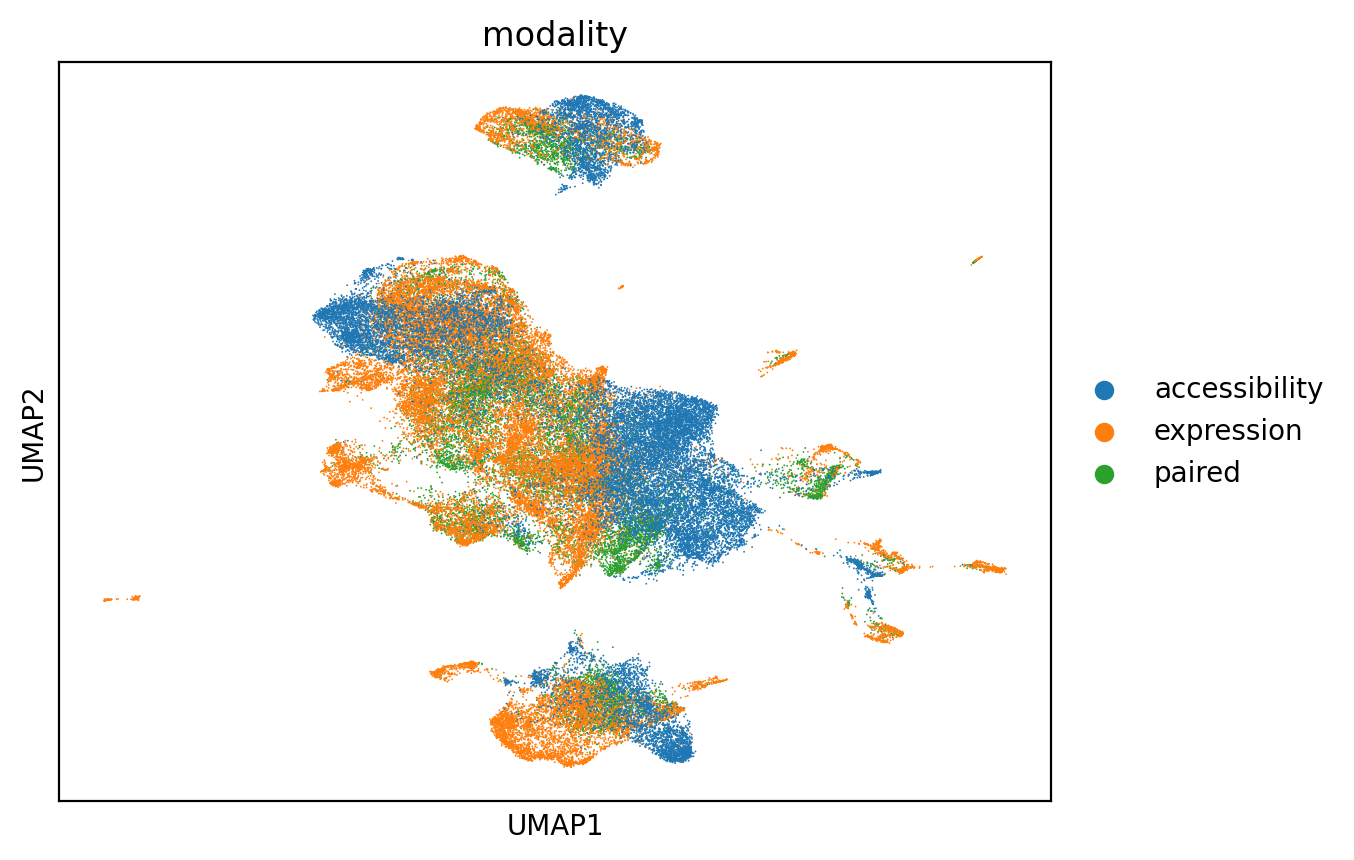

In [ ]:
adata_mvi.obsm["MultiVI_latent"] = mvi.get_latent_representation()
sc.pp.neighbors(adata_mvi, use_rep="MultiVI_latent")
sc.tl.umap(adata_mvi, min_dist=0.2)
sc.pl.umap(adata_mvi, color="modality")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


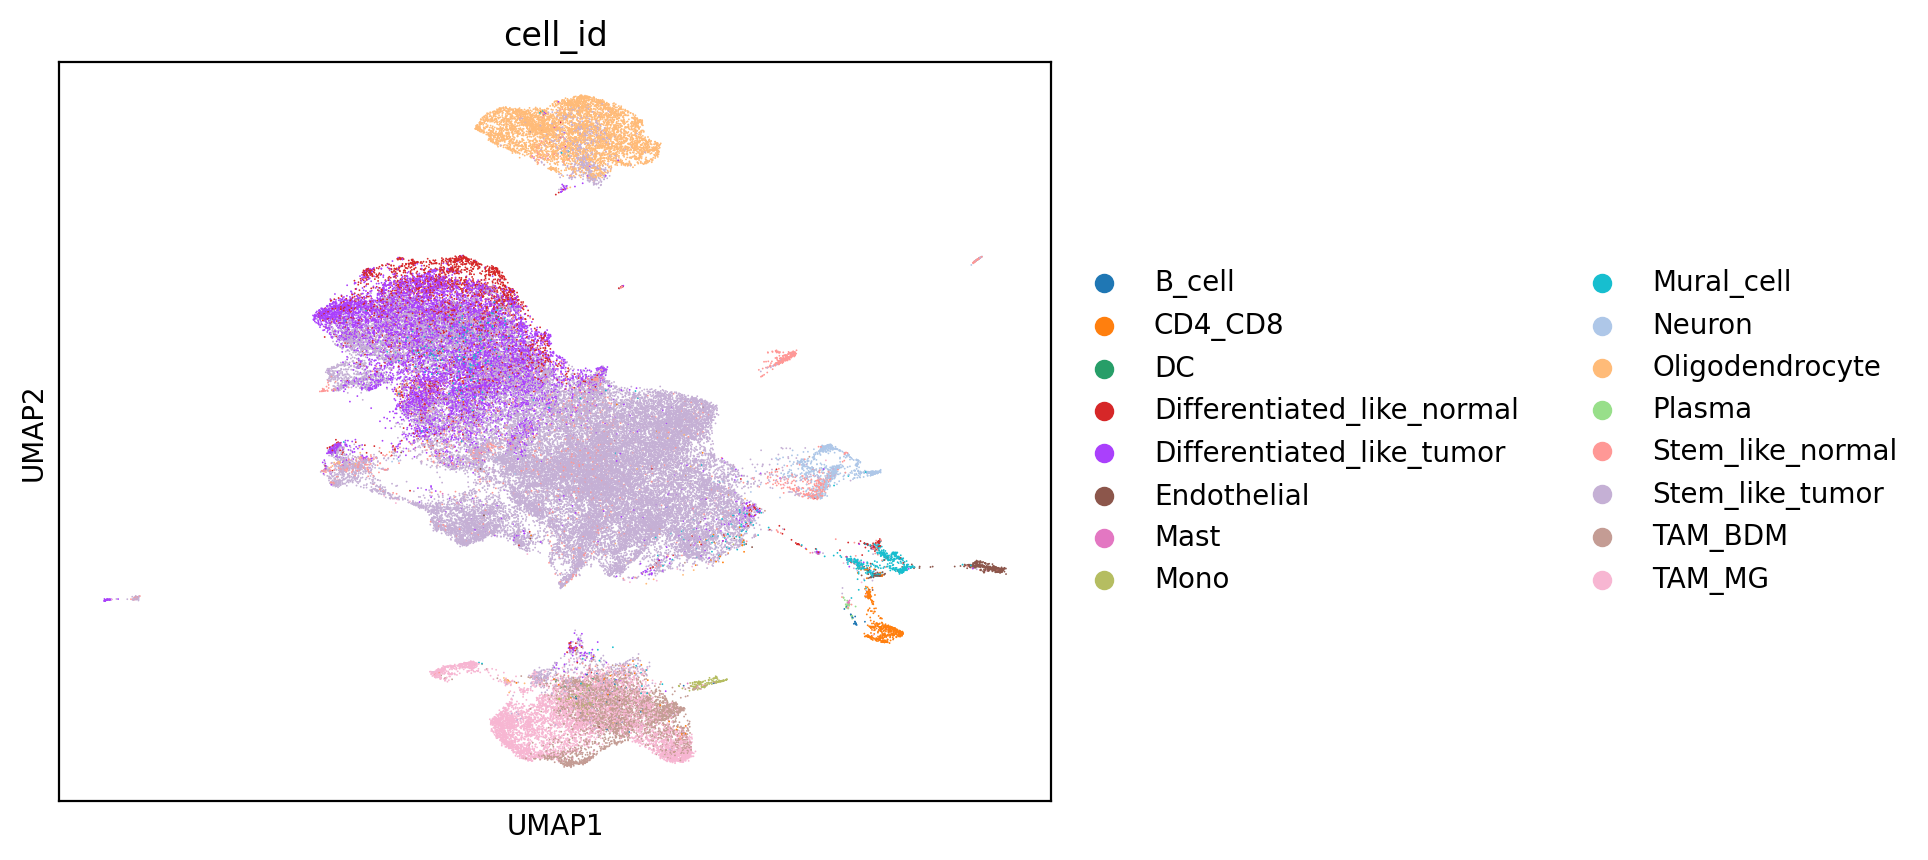

In [ ]:
sc.pl.umap(adata_mvi, color="cell_id")

/home/cruiz2/miniconda3/envs/multi_integration/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


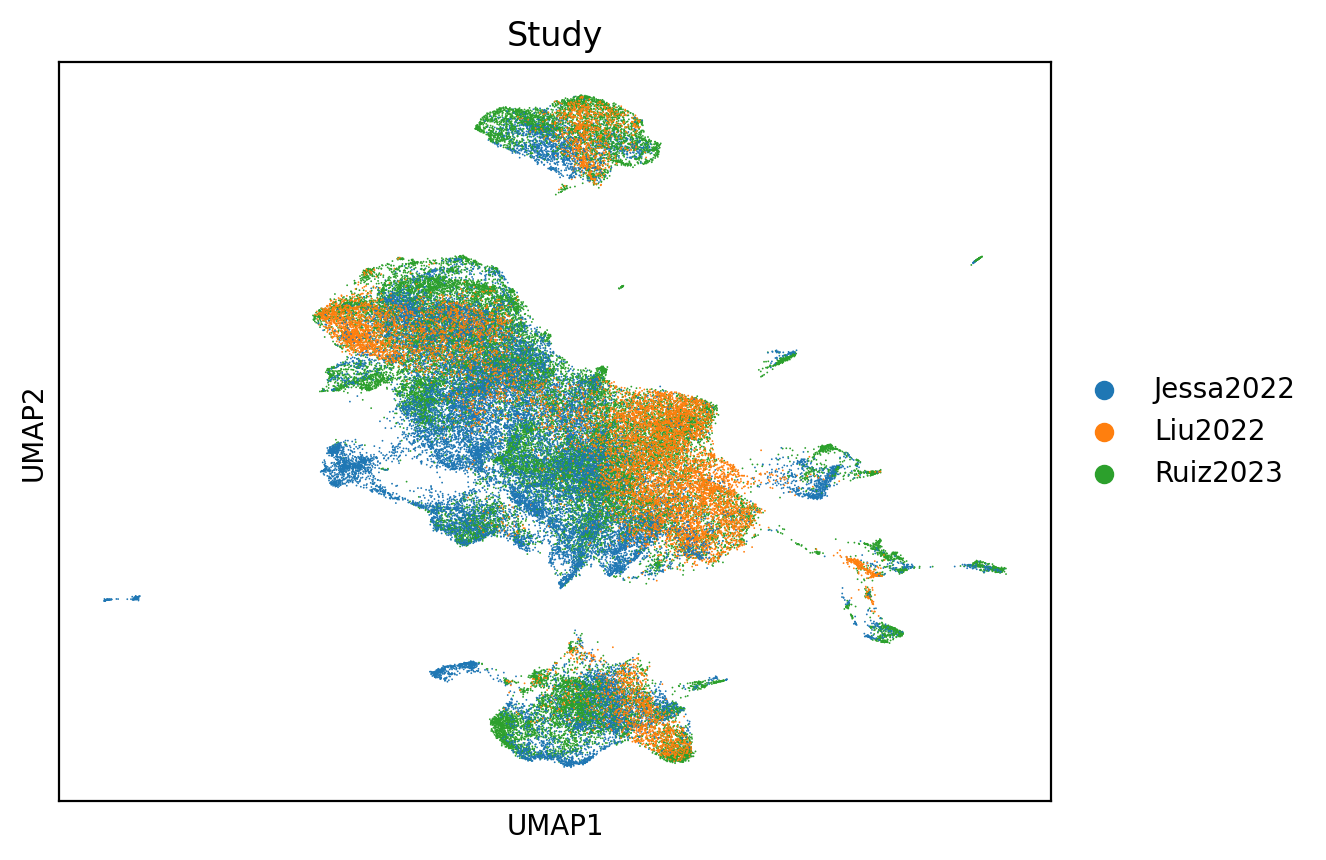

In [ ]:
sc.pl.umap(adata_mvi, color="Study")

In [ ]:
mvi.save('mosaic_integration/multivi/trained_multivi_sampleID')

```
TypeError: Can't implicitly convert non-string objects to strings
Above error raised while writing key 'vst.variable' of <class 'h5py._hl.group.Group'> to /
```

In [ ]:
del adata_mvi.var['vst.variable']

In [ ]:
adata_mvi.write("mosaic_integration/multivi/trained_multivi_sampleID/dmg_atlas_subset_multivi.h5ad", compression="gzip") 